In [ ]:
# pip3 install --upgrade tensorflow_hub

In [ ]:
import numpy as np
import cv2

import os

import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import Lambda
m = tf.keras.Sequential([
    Lambda(lambda x:hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-classification/2")(x))
])
m.build([None, 224, 224, 3])

In [5]:
m.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 1001)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
tf.keras.utils.get_file(fname='ImageNetLabels.txt', # Changed fname to just the filename
                        origin='https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt',
                        cache_dir='/content/')

10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'/content/datasets/ImageNetLabels.txt'

In [7]:
with open("/content/datasets/ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()

In [8]:
print(image_labels)
print(len(image_labels))

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', '

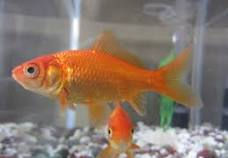

In [10]:
import cv2
from google.colab.patches import cv2_imshow
mypic = cv2.imread("/content/goldfish.jpeg")
cv2_imshow(mypic)

In [11]:
mypic = mypic.astype("float32")/255
mypic = cv2.resize(mypic,(224,224))
mybatch = mypic.reshape(1,224,224,3)
m.predict(mybatch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


array([[ 4.6866000e-01,  5.4508915e+00,  5.8154120e+00, ...,
        -2.2825685e+00,  3.0914471e-03, -6.7790616e-01]], dtype=float32)

In [14]:
prob = m.predict(mybatch)
print(np.argmax(prob))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
85


In [16]:
image_labels[85]

'peacock'

In [17]:
pwd

'/content'

In [18]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(fname='flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [19]:
data_dir = "/content/datasets/flower_photos/flower_photos"

In [20]:
data_dir.split()

['/content/datasets/flower_photos/flower_photos']

In [21]:
import pathlib
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib._local.PosixPath

In [22]:
list(data_dir.glob("roses/*"))

[PosixPath('/content/datasets/flower_photos/flower_photos/roses/16691277899_9433f39155_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/18563353954_b761d97155_m.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/4242976586_607a8f9843_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/1461381091_aaaa663bbe_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/2265390547_2409007cef_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/9159362388_c6f4cf3812_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/3268459296_a7346c6b2c.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/14019883858_e5d2a0ec10_n.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/16316557109_7fc55c1cbc_m.jpg'),
 PosixPath('/content/datasets/flower_photos/flower_photos/roses/4503599544_3822e7d1be.jpg'),
 PosixPath('/content/datasets/flower_photos/flower

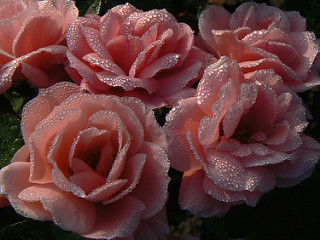

In [23]:
cv2_imshow(cv2.imread('/content/datasets/flower_photos/flower_photos/roses/272481307_1eb47ba3e0_n.jpg'))

In [24]:
len(list(data_dir.glob("roses/*")))

641

In [25]:
print(len(list(data_dir.glob("roses/*"))))
print(len(list(data_dir.glob("daisy/*"))))
print(len(list(data_dir.glob("dandelion/*"))))
print(len(list(data_dir.glob("sunflowers/*"))))
print(len(list(data_dir.glob("tulips/*"))))

641
633
898
699
799


In [26]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [27]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_img = cv2.resize(img,(224,224))
        resized_img = resized_img.astype("float32")/255
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [28]:
len(X)

3670

In [29]:
X = np.array(X)
y = np.array(y)

In [30]:
X.shape

(3670, 224, 224, 3)

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1 ,stratify=y ,random_state=0)

In [ ]:
# feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

# pretrained_model_without_top_layer = hub.KerasLayer(
#     feature_extractor_model, input_shape=(224, 224, 3), trainable=False)
# pretrained_model_without_top_layer

In [32]:
model = tf.keras.Sequential([
  Lambda(lambda x : hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-224-feature-vector/2")(x)),
  keras.layers.Flatten(),
  keras.layers.Dense(200),
  keras.layers.Dense(5,activation='softmax')
])
model.build([None,224,224,3])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       256,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,205 (1004.71 KB)

 Trainable params: 257,205 (1004.71 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=['acc'])

model.fit(X_train,y_train, epochs=5,batch_size=32)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 34s 125ms/step - acc: 0.7744 - loss: 0.6971
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.8707 - loss: 0.3611
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9034 - loss: 0.2590
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9258 - loss: 0.2019
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - acc: 0.9388 - loss: 0.1660


In [ ]:
# m.compile(
#   optimizer="adam",
#   loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#   metrics=['acc'])

# m.fit(X_train, y_train, epochs=5)

In [34]:
label_dict = {v:k for k,v in flowers_labels_dict.items()}

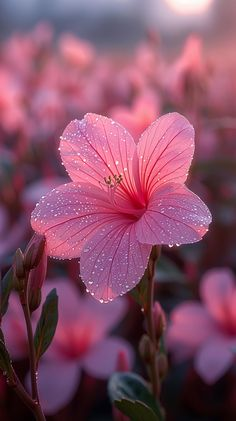

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


'sunflowers'

In [40]:
demopic = cv2.imread("/content/flower1.jpg")
cv2_imshow(demopic)
demopic = cv2.resize(demopic,(224,224))
demopic = demopic.astype("float32")/255
batch = demopic.reshape(1,224,224,3)
label_dict[np.argmax(model.predict(batch))]
